# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [68]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [4]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [27]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [29]:
# cantidad de nulos para users
print("plans", plans.isna().sum())   # Cantidad de valores nulos)
print("plans", plans.isna().mean())  # Proporción de valores nulos)

plans plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64
plans plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [30]:
# cantidad de nulos para usage
print("usage", usage.isna().sum())   # Cantidad de valores nulos)
print("usage", usage.isna().mean())  # Proporción de valores nulos)

usage id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
usage id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
**la columna date,duration y length tienen valores faltantes
date        0.00125% Eliminar esos registros
duration    0.55190% Mantener nulos o eliminar la columna si no aporta valor al análisis.
length      0.44740% Mantener nulos o eliminar la columna si no aporta valor al análisis.**
-   
- Indica qué harías: ¿imputar, eliminar, ignorar?
**date Eliminar esos registros
duration Mantener nulos o eliminar la columna si no aporta valor al análisis.
length    Mantener nulos o eliminar la columna si no aporta valor al análisis.**

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [40]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` .no presenta errores,ni centinels 
- La columna `age` min tiene un sentinel valor de -999,std alta 

In [41]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`no hay sentinels ni valores altos 
- Las columnas duration y length muestran valores faltantes 

In [49]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n--- Columna: {col} ---")
    print(users[col].unique())
    print(f"Cantidad de categorías: {users[col].nunique()}")


--- Columna: city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Cantidad de categorías: 7

--- Columna: plan ---
['Basico' 'Premium']
Cantidad de categorías: 2


- La columna `city` hay una ciudad que tiene el valor "?" y otra con valor nan en minusculas
- La columna `plan` nose encontraron valores inesperados

In [54]:
# explorar columna categórica de usage
usage['type'].unique() # valores unicos

array(['call', 'text'], dtype=object)

- La columna `type` solo tiene salidas de call y text no tiene sentinels,valores inesperados,ni diferente formato

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- **en las columnas age,"?" y nan**
- ¿Qué acción tomarías?
- **en la columna age reemplazaria los valores -999 a NA lo mismo para nan y "?" cambiarlo por "unknown"**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [9]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')  # completa el código

In [26]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')  # completa el código

In [20]:
# Revisar los años presentes en `reg_date` de users
years_reg_date = users['reg_date'].dt.year
print("Años únicos en reg_date:", years_reg_date.unique())
print("Conteo por año:")
print(years_reg_date.value_counts().sort_index())

Años únicos en reg_date: [2022 2026 2023 2024]
Conteo por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, hay un año no transucrrido con 40 usuarios registrados 

In [25]:
# 1. Recargar el dataset usage para ver los datos originales
usage_original = pd.read_csv('/datasets/usage.csv')

# 2. Revisar el formato original de las fechas
print("Tipo original de 'date':", usage_original['date'].dtype)
print("Primeras 10 fechas originales:")
print(usage_original['date'].head(10))
print("Valores únicos (primeros 20):")
print(usage_original['date'].unique()[:20])

Tipo original de 'date': object
Primeras 10 fechas originales:
0    2024-01-01 00:00:00.000000000
1    2024-01-01 00:06:30.969774244
2    2024-01-01 00:13:01.939548488
3    2024-01-01 00:19:32.909322733
4    2024-01-01 00:26:03.879096977
5    2024-01-01 00:32:34.848871221
6    2024-01-01 00:39:05.818645466
7    2024-01-01 00:45:36.788419710
8    2024-01-01 00:52:07.758193954
9    2024-01-01 00:58:38.727968199
Name: date, dtype: object
Valores únicos (primeros 20):
['2024-01-01 00:00:00.000000000' '2024-01-01 00:06:30.969774244'
 '2024-01-01 00:13:01.939548488' '2024-01-01 00:19:32.909322733'
 '2024-01-01 00:26:03.879096977' '2024-01-01 00:32:34.848871221'
 '2024-01-01 00:39:05.818645466' '2024-01-01 00:45:36.788419710'
 '2024-01-01 00:52:07.758193954' '2024-01-01 00:58:38.727968199'
 '2024-01-01 01:05:09.697742443' '2024-01-01 01:11:40.667516687'
 '2024-01-01 01:18:11.637290932' '2024-01-01 01:24:42.607065176'
 '2024-01-01 01:31:13.576839420' '2024-01-01 01:37:44.546613665'
 '2024-01-0

In [24]:
# Verificar el tipo de dato actual de la columna
print("Tipo de dato de 'date':", usage['date'].dtype)
print("Primeros 5 valores:")
print(usage['date'].head())
print("Valores nulos:", usage['date'].isna().sum())

Tipo de dato de 'date': int64
Primeros 5 valores:
0    39950
1    39950
2    39950
3    39950
4    39950
Name: date, dtype: int64
Valores nulos: 0


In [27]:
# 1. Recargar el dataset usage para empezar limpio
usage = pd.read_csv('/datasets/usage.csv')

# 2. Convertir la columna date correctamente
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# 3. Verificar que la conversión funcionó
print("Tipo de dato después de conversión:", usage['date'].dtype)
print("Primeros 5 valores:")
print(usage['date'].head())

Tipo de dato después de conversión: datetime64[ns]
Primeros 5 valores:
0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


In [28]:
# Revisar los años presentes en `date` de usage
# Ahora sí podrás hacer esto:
years_date = usage['date'].dt.year
print("Años únicos en date:", years_date.unique())
print("Conteo por año:")
print(years_date.value_counts().sort_index())

Años únicos en date: [2024.   nan]
Conteo por año:
2024.0    39950
Name: date, dtype: int64


En `date`, solo hay datos del 2024 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- **hay años que aun no transcurren 2026 con 40 usaurios regsitrados**
- ¿Qué harías con ellas?
- **Eliminar solo la filas con fehcas imposibles**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [45]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()

users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [49]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)
# Verificar cambios
users['city'].head(10)

0    Medellín
1        <NA>
2        CDMX
3      Bogotá
4         GDL
5         MTY
6      Bogotá
7    Medellín
8        CDMX
9      Bogotá
Name: city, dtype: object

In [51]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].replace("2026", pd.NA)

# Verificar cambios
users['reg_date'].isna().sum()
users[users['reg_date'].isna()].head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [57]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_missing'] = usage['duration'].isna()
usage.groupby('type')['duration_missing'].mean()

type
call    0.000000
text    0.999276
Name: duration_missing, dtype: float64

In [58]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_missing'] = usage['length'].isna()
usage.groupby('type')['length_missing'].mean()

type
call    0.99933
text    0.00000
Name: length_missing, dtype: float64

 Haz doble clic aquíy escribe que tu diagnostico de nulos en
**`duration` y `length`en `duration`los nulos en call son MAR y en `length` los nulos en text son MAR** 
Mantener los nulos sin imputar Los valores nulos en duration y length corresponden a casos donde la métrica no aplica según el tipo de evento. Imputarlos introduciría ruido, sesgo y valores artificiales que no representan el comportamiento real del usuario.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [7]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('type', lambda x: (x == 'text').sum()),
    cant_llamadas = ('type', lambda x: (x == 'call').sum()),
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [8]:
# Renombrar columnas
# No se requiere renombrar columnas ya se realizo en el paso anterior 
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [9]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how= "left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [68]:
users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN
...,...,...,...,...,...,...,...,...
3995,13995,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaN
3996,13996,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaN
3997,13997,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaN
3998,13998,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaN


In [76]:
# Resumen estadístico de las columnas numéricas

print( users[["user_id","age"]].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    48.122250
std     1154.844867    17.690408
min    10000.000000    18.000000
25%    10999.750000    33.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


In [77]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

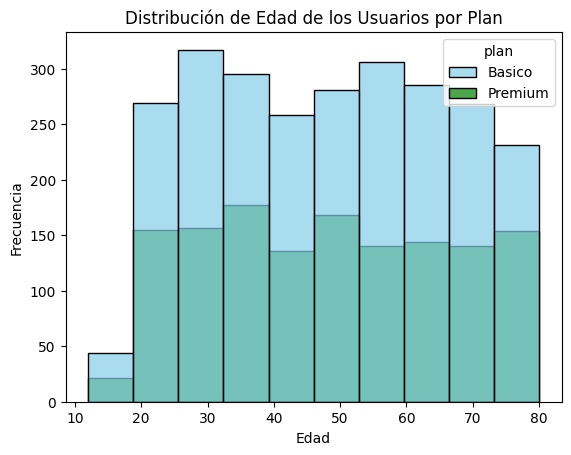

In [63]:
# Histograma para visualizar la edad (age) separado por plan




sns.histplot(data=users, x="age", hue="plan", bins=10, binrange=(12,80),
             palette=['skyblue','green'], alpha=0.7)
plt.title('Distribución de Edad de los Usuarios por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show(
)



💡Insights: 
- Distribución
- Dentro del plan Premium, **hay mayor proporción de usauarios con rango de edad de 30 y 60 años y hay pocos valores en edades 12-20**

**Hay diferencia entre un plan y otro hay mas usuarios en un plan que en otro**

¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)
**"Sesgada ala derecha "**



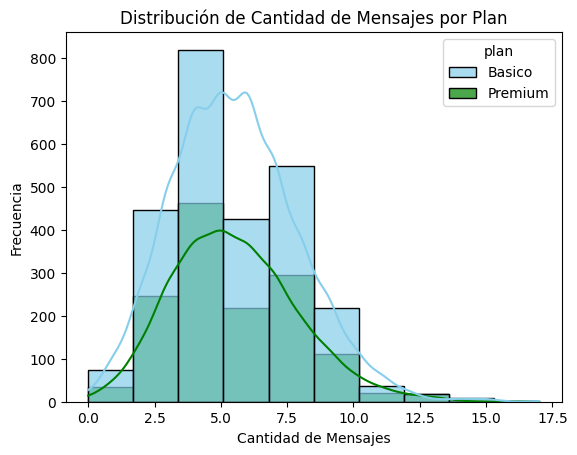

In [48]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=10, kde=True,
             palette=['skyblue','green'], alpha=0.7)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- **"Dentro del plan Premium, hay menor proporcion de usuarios que sobrepasan la cantidad de mensajes de su plan "**

**"Los usuarios del plan Básico y tienden a sobrepasar la cantidad de mensajes  enviar 5.0 mas mensajes con mayor frecuencia del plan premium**
  
¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)
**Segada ala derecha**


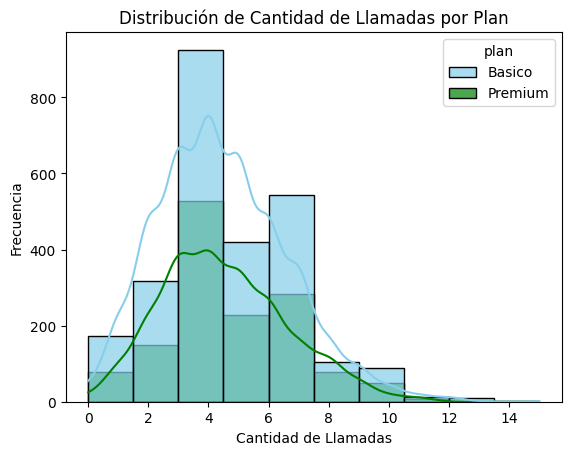

In [49]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=10, kde=True,
             palette=['skyblue','green'], alpha=0.7)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución ...
- **"Dentro del plan Premium, hay mayor proporción de usaurios que realizan 5 llamadas mas sobre le promedio (frecuencia) 400 y en el plan basico realizan las 5 llamadas con menor frecuencia vs el plan premium**
- 
**"Los usuarios Premium  tienden a hacer mas  llamadas y enviar menos  mensajes hay menor cantidad de usuarios que realizan mas llamadas entre 12 y 14**


¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Sesgada ala derecha**


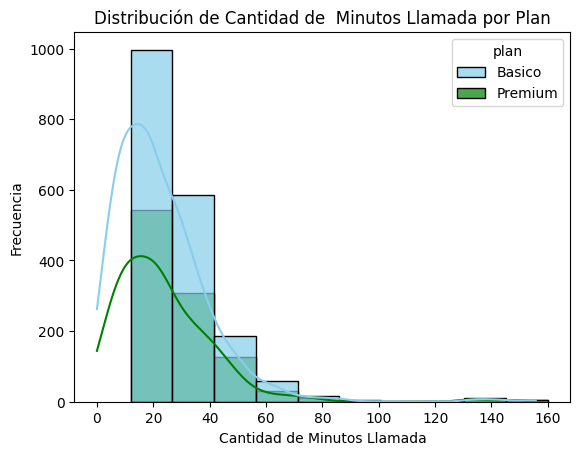

In [86]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", bins=10, binrange=(12,160),kde=True,
             palette=['skyblue','green'], alpha=0.7)

plt.title('Distribución de Cantidad de  Minutos Llamada por Plan')
plt.xlabel('Cantidad de Minutos Llamada')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
-**Dentro del plan Premium, hay mayor proporción de minutos por llamada la mayoria se mantienen por debajo del limite de cantidad de minutos llamda de su plan  solo un rango muy bajo de usuarios utilizan mas minutos llamada entre 140 y 160**

**"Los usuarios Básico tienden a sobrepasar la cantidad de minutos llamada**

¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)
**Sesgada ala derecha**


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

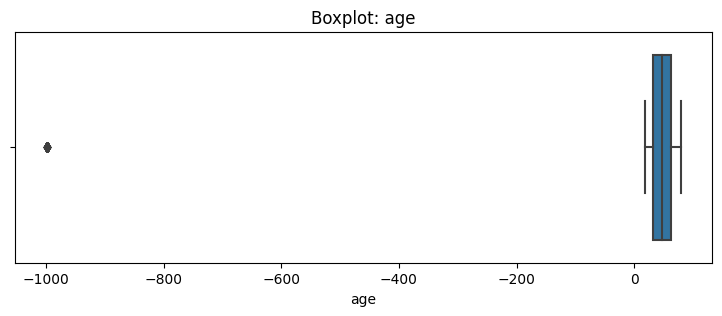

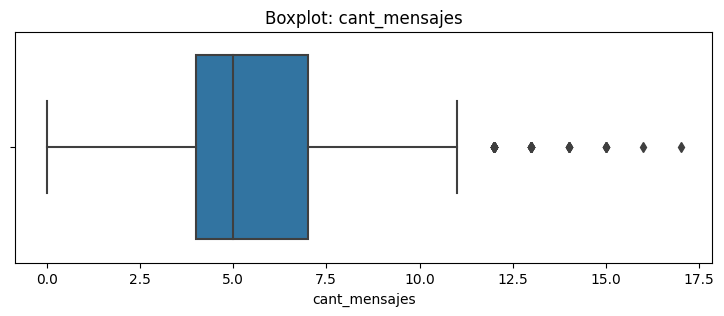

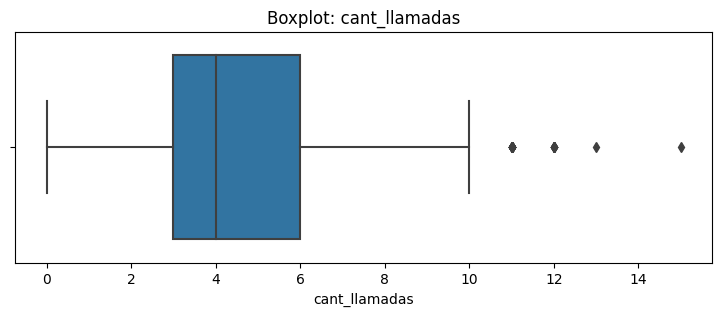

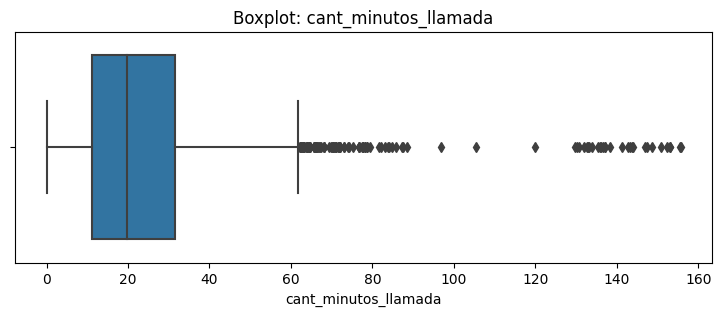

In [55]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()



💡Insights: 
- Age: ...(presenta o no outliers) **Si presenta outliers con valores negativos**
- cant_mensajes: ...**Presenta solo 6 outliers**
- cant_llamadas: ...**Presenta solo 4 outliers**
- cant_minutos_llamada: ....**Presenta muchos outliers**

In [62]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# calcular Q1, Q3 e IQR
Q1 = user_profile[columnas_limites].quantile(0.25)  #Calcula Q1, Q3 e IQR.
Q3 = user_profile[columnas_limites].quantile(0.75)  # Calcula Q1, Q3 e IQR.
IQR = Q3 - Q1  # tu código aquí

# calcular límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR  # Calcula los límites inferior y superior.
limite_superior = Q3 + 1.5 * IQR  # Calcula los límites inferior y superior.

# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(user_profile[user_profile[columnas_limites] < limite_inferior])
  

print("\nRegistros arriba del límite superior")
print(user_profile[user_profile[columnas_limites] > limite_superior])


Primer cuartil:  age                     32.00
cant_mensajes            4.00
cant_llamadas            3.00
cant_minutos_llamada    11.12
Name: 0.25, dtype: float64
Tercer cuartil:  age                     63.000
cant_mensajes            7.000
cant_llamadas            6.000
cant_minutos_llamada    31.415
Name: 0.75, dtype: float64
IQR:  age                     31.000
cant_mensajes            3.000
cant_llamadas            3.000
cant_minutos_llamada    20.295
dtype: float64

Registros abajo del límite inferior
      user_id first_name last_name  age city reg_date plan churn_date  \
0         NaN        NaN       NaN  NaN  NaN      NaN  NaN        NaN   
1         NaN        NaN       NaN  NaN  NaN      NaN  NaN        NaN   
2         NaN        NaN       NaN  NaN  NaN      NaN  NaN        NaN   
3         NaN        NaN       NaN  NaN  NaN      NaN  NaN        NaN   
4         NaN        NaN       NaN  NaN  NaN      NaN  NaN        NaN   
...       ...        ...       ...  ...  ...    

In [61]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,33.739750,5.524381,4.478120,23.317054
std,123.232257,2.358416,2.144238,18.168095
min,-999.000000,0.000000,0.000000,0.000000
25%,32.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- **MANTENER ¿Porque? Si tiene entre 5% y 30%, generalmente se investiga para imputar o dejar como nulos.**
- 
- cant_llamadas: mantener o no outliers, porqué?
- **MANTENER ¿Porque? Si es menor al 5%, suele ser un caso simple de imputación o dejar como nulos**
-
-  cant_minutos_llamada: mantener o no outliers, porqué?
- **NO MANTENER ¿Porque? Si una columna tiene más del 80–90% de nulos, normalmente se ignora o elimina.**


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [76]:
# Crear columna grupo_uso

user_profile["grupo_uso"] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
     np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)



In [81]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [79]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    (user_profile['age'] < 30),
    'Joven',
     np.where(
        (user_profile['age'] <  60),
        'Adulto',
        'Adulto Mayor'
    )
)

In [80]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

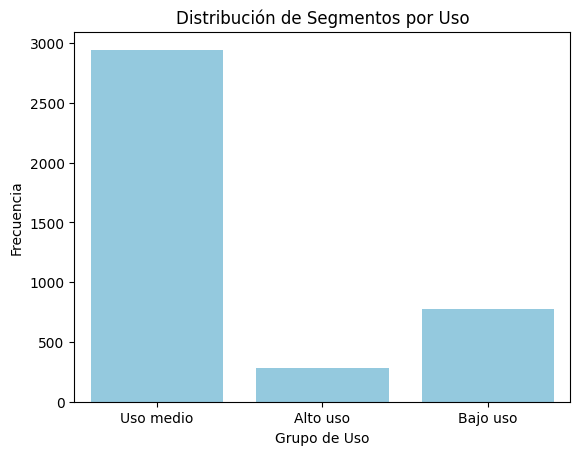

In [83]:
# Visualización de los segmentos por uso - CORRECTO
sns.countplot(x=user_profile['grupo_uso'], color='skyblue')
plt.title('Distribución de Segmentos por Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Frecuencia')
plt.show()

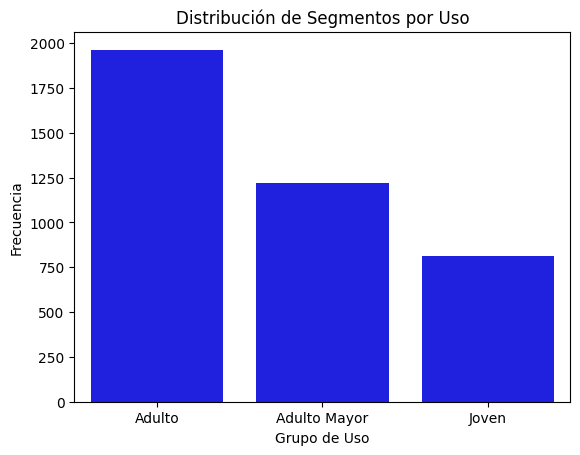

In [85]:
# Visualización de los segmentos por edad
sns.countplot(x=user_profile['grupo_edad'], color='blue')
plt.title('Distribución de Segmentos por Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Frecuencia')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- **¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?**

**Problemas detectados**
Valores nulos en columnas clave del dataset usage:
duration: 55% nulos (solo 17,924 valores no nulos).
length: 44.7% nulos (solo 22,104 valores no nulos).

**Posibles sentinels:**

En age existía el sentinel -999, que fue reemplazado por la mediana.
Después de limpiar, la distribución se mantuvo estable.

**Outliers en columnas numéricas:**
length tenía valores altos (hasta 1490), pero no eran errores, solo uso extremo.

**Dataset plans con solo 2 filas:**
No presentaba problemas, pero su tamaño limita análisis avanzados.

**Porcentajes relevantes**
55% de duration estaba vacío.
44.7% de length estaba vacío.
<1% de age tenía sentinels (estimado por tu limpieza)

- **¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?**
-
- **Usando la columna grupo_uso:**

**Segmentos creados**
Bajo uso → llamadas < 5 y mensajes < 5
Uso medio → llamadas < 10 y mensajes < 10
Alto uso → resto de casos

**Comportamiento por edad**
Con base en la distribución que analizamos:
La edad está sesgada a la derecha, concentrada entre 30 y 60 años.
No hay diferencias fuertes entre planes, pero sí entre niveles de uso:

**Bajo uso**
Usuarios más jóvenes o adultos con poco uso del servicio.
Pueden ser clientes nuevos o con baja dependencia del teléfono.

**Uso medio**
Usuarios típicos, con uso estable.
Edad promedio ligeramente mayor que el segmento de bajo uso.

**Alto uso**
Usuarios más intensivos, con más llamadas y mensajes.
Suelen estar en el rango 35–55 años, donde hay mayor actividad laboral.  

-**¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?**

**Segmento más valioso: Alto uso**
**Porque:**

Generan mayor consumo de servicios (llamadas, mensajes, datos).
Son menos sensibles al precio.
Tienen mayor probabilidad de contratar planes más completos.
Representan oportunidades de upselling y retención.

**Segmento con potencial: Uso medio**
Pueden migrar a planes superiores si se les ofrece valor adicional.
Son estables y menos propensos a churn.

**Segmento menos valioso: Bajo uso**
Bajo ARPU (ingreso promedio por usuario).
Mayor probabilidad de churn.
Pueden ser clientes de entrada o de bajo compromiso.

- **¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?**

**Outliers detectados**
length con valores muy altos (hasta 1490).
duration con llamadas de hasta 120 segundos (no extremo, pero notable).
Usuarios con muchas más llamadas o mensajes que el promedio.

**Implicaciones**
Podrían ser usuarios corporativos o heavy users.
Representan oportunidades para:
planes premium,
paquetes ilimitados,
servicios adicionales.

**También pueden indicar:**
abuso del servicio,
uso compartido de líneas,
necesidad de monitoreo.

-**¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?**

**1. Crear un plan Premium para usuarios de Alto uso**
Llamadas y mensajes ilimitados.
Datos adicionales.
Beneficios exclusivos (roaming, atención prioritaria).

**2. Ofrecer un plan intermedio para el segmento de Uso medio
Más datos y minutos que el plan básico.**
Precio competitivo.
Ideal para migración desde bajo uso.

**3. Crear un plan económico para Bajo uso
Pocos minutos y mensajes.**
Precio muy bajo.
Ideal para retener clientes que usan poco el servicio.

**4. Detectar heavy users y ofrecerles paquetes personalizados
Basado en outliers de length y duration.**
Paquetes de datos o minutos adicionales.

**5. Monitorear patrones de uso extremo
Para evitar abuso del servicio.**
Para identificar oportunidades de negocio corporativo.

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Existencia de valores sentinel como -999 en la columna age, distorsionando la media y la desviación estándar.
Altos porcentajes de valores nulos en el dataset de uso:
55% de duration vacío
44.7% de length vacío
Presencia de outliers reales en duración y longitud de llamadas, que no son errores pero sí representan uso extremo.
Distribución de edad sesgada a la derecha, concentrada entre 30 y 60 años.


🔍 **Segmentos por Edad**
- La mayoría de los usuarios se concentran entre 30 y 60 años, lo que indica una base de clientes adulta y estable.
-Los usuarios jóvenes (12–25) son minoría y muestran menor actividad, mientras que los mayores de 60 representan un segmento pequeño pero consistente.


📊 **Segmentos por Nivel de Uso**
Bajo uso: clientes con muy pocas llamadas y mensajes; bajo ARPU y mayor riesgo de churn.
Uso medio: usuarios estables, con potencial de migrar a planes superiores.
Alto uso: heavy users con mayor consumo, mayor valor y menor sensibilidad al precio.


➡️ **Esto sugiere que ...**

ConnectaTel tiene una base sólida de usuarios adultos con patrones de uso consistentes.
El segmento de alto uso es el más rentable y debe ser priorizado en estrategias de retención y upselling.
El segmento de uso medio representa una oportunidad clara para incrementar ingresos mediante planes intermedios.
El segmento de bajo uso requiere ofertas económicas para evitar abandono.
Los outliers indican la existencia de usuarios corporativos o intensivos que podrían beneficiarse de planes premium.

💡 **Recomendaciones**
Crear un plan premium para heavy users con beneficios como minutos ilimitados, más datos y servicios adicionales.
Desarrollar un plan intermedio para usuarios de uso medio que incentive la migración desde planes básicos.
Implementar un plan económico para usuarios de bajo uso, enfocado en retención.
Diseñar ofertas personalizadas para usuarios con patrones de uso extremo (outliers), como paquetes adicionales o planes corporativos.
Monitorear continuamente los patrones de uso para detectar oportunidades de upselling y prevenir abuso del servicio. 


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`